## IMPORTS

In [17]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import torch.optim as optim
from tqdm import tqdm
from sklearn.metrics import roc_curve, auc

## Q1: DATA

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


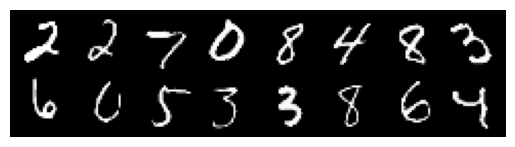

In [9]:
# Transformation pipeline to convert images to Tensors and normalize them
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load the MNIST training dataset
trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

# Load the MNIST test dataset
testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=8, shuffle=False)

# Get a single batch of images
images, labels = next(iter(trainloader))

# Display a grid of the first 16 images from the batch
img_grid = torchvision.utils.make_grid(images[:16])
npimg = img_grid.numpy()
plt.imshow(np.transpose(npimg, (1, 2, 0)))
plt.axis('off')
plt.show()

## Q2: Auto-encoder

In [ ]:
# Define the size of the latent space
latent_dims = 10

class Encoder(nn.Module):

    def __init__(self):
        super(Encoder, self).__init__()
        self.conv_layers = nn.Sequential(
            # Input: 1 x 28 x 28
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1), # -> 16 x 14 x 14
            nn.ReLU(True),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # -> 32 x 7 x 7
            nn.ReLU(True),
            nn.Conv2d(32, 64, kernel_size=7) # -> 64 x 1 x 1
        )

    def forward(self, x):
        x = self.conv_layers(x)
        return x

class Decoder(nn.Module):

    def __init__(self):
        super(Decoder, self).__init__()
        self.deconv_layers = nn.Sequential(
            # Input: 64 x 1 x 1
            nn.ConvTranspose2d(64, 32, kernel_size=7), # -> 32 x 7 x 7
            nn.ReLU(True),
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1), # -> 16 x 14 x 14
            nn.ReLU(True),
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1), # -> 1 x 28 x 28
            nn.Tanh() # To scale output pixels to [-1, 1]
        )

    def forward(self, x):
        x = self.deconv_layers(x)
        return x

class Autoencoder(nn.Module):

    def __init__(self):
        super(Autoencoder, self).__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()

    def forward(self, x):
        latent = self.encoder(x)
        x_recon = self.decoder(latent)
        return x_recon

autoencoder = Autoencoder()

## Q3: 

In [ ]:
# the optimizer and the reconstruction loss function (L_con)
optimizer = optim.Adam(autoencoder.parameters(), lr=1e-3)
reconstruction_loss = nn.MSELoss()

Starting Autoencoder Training...


  0%|          | 0/938 [00:00<?, ?it/s]

Epoch [5/5]: 100%|██████████| 938/938 [01:35<00:00,  9.78it/s, loss=0.0095] 



Training Complete.
Displaying original and reconstructed images from the test set.


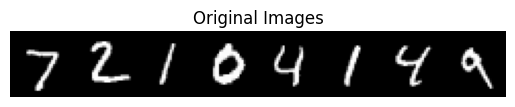

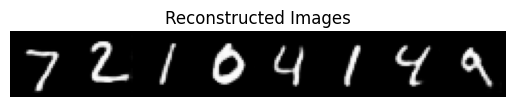

In [ ]:
num_epochs = 5
print("Starting Autoencoder Training...")
for epoch in range(num_epochs):

    loop = tqdm(trainloader, leave=True)
    for data in loop:
        img, _ = data
        recon = autoencoder(img)
        loss = reconstruction_loss(recon, img)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


        loop.set_description(f"Epoch [{epoch+1}/{num_epochs}]")
        loop.set_postfix(loss=loss.item())

print("\nTraining Complete.")

# --- Visualize reconstruction results ---
test_images, _ = next(iter(testloader))
with torch.no_grad():
    reconstructed_images = autoencoder(test_images)

def show_image_grid(imgs, title=""):
    # Un-normalize for display
    imgs = imgs / 2 + 0.5
    grid = torchvision.utils.make_grid(imgs)
    npgrid = grid.numpy()
    plt.imshow(np.transpose(npgrid, (1, 2, 0)))
    plt.title(title)
    plt.axis('off')
    plt.show()

print("Displaying original and reconstructed images from the test set.")
show_image_grid(test_images, "Original Images")
show_image_grid(reconstructed_images, "Reconstructed Images")

## Q4: Use the GANomaly Model designed as a shared solution for three parts:
1. Compressed representation of the input image (during the reconstruction stage)
2. Compressed representation of the reconstructed image (as a second encoder)
3. Using the encoder output as input to the discriminator section

In [ ]:
class Encoder(nn.Module):
    def __init__(self):
        super(Encoder, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=7)
        )
    def forward(self, x):
        return self.conv_layers(x)

class Decoder(nn.Module):
    def __init__(self):
        super(Decoder, self).__init__()
        self.deconv_layers = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=7),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Tanh()
        )
    def forward(self, x):
        return self.deconv_layers(x)

class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()
    def forward(self, x):
        return self.decoder(self.encoder(x))

class Discriminator(nn.Module):
    def __init__(self, latent_dim=64):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )
    def forward(self, z):
        z = z.view(z.size(0), -1)
        return self.model(z)

class GANomaly(nn.Module):
    def __init__(self):
        super(GANomaly, self).__init__()
        self.generator = Autoencoder()
        self.discriminator = Discriminator()
    def forward(self, x):
        z = self.generator.encoder(x)
        x_hat = self.generator.decoder(z)
        z_hat = self.generator.encoder(x_hat)

        return x, z, x_hat, z_hat

ganomaly_model = GANomaly()

Corrected GANomaly model created successfully.
GANomaly(
  (generator): Autoencoder(
    (encoder): Encoder(
      (conv_layers): Sequential(
        (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (1): ReLU()
        (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (3): ReLU()
        (4): Conv2d(32, 64, kernel_size=(7, 7), stride=(1, 1))
      )
    )
    (decoder): Decoder(
      (deconv_layers): Sequential(
        (0): ConvTranspose2d(64, 32, kernel_size=(7, 7), stride=(1, 1))
        (1): ReLU()
        (2): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
        (3): ReLU()
        (4): ConvTranspose2d(16, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
        (5): Tanh()
      )
    )
  )
  (discriminator): Discriminator(
    (model): Sequential(
      (0): Linear(in_features=64, out_features=512, bias=True)
      (1): LeakyReLU(negative_sl

## Q7 + Q8: Training + ROC

--- Starting Training for Normal Class: 0 ---



--- Starting Evaluation ---


Evaluating: 100%|██████████| 157/157 [00:10<00:00, 14.60it/s]


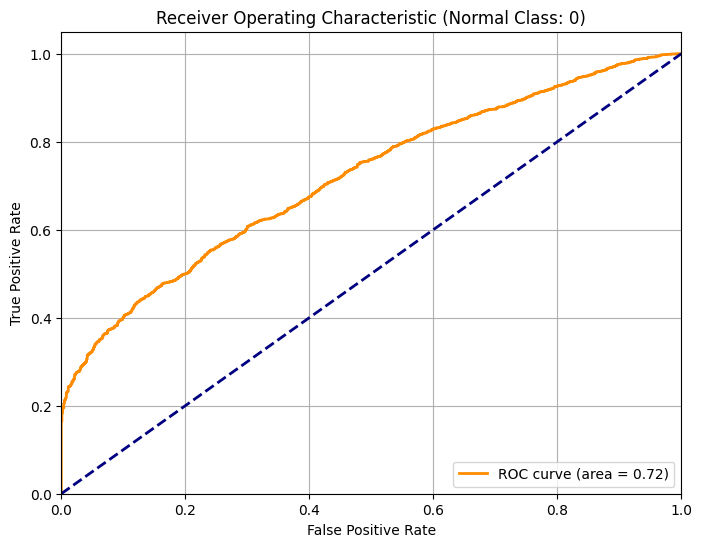


AUC Score for normal class '0': 0.7176


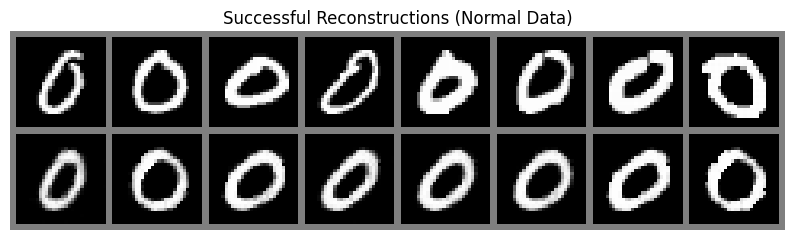

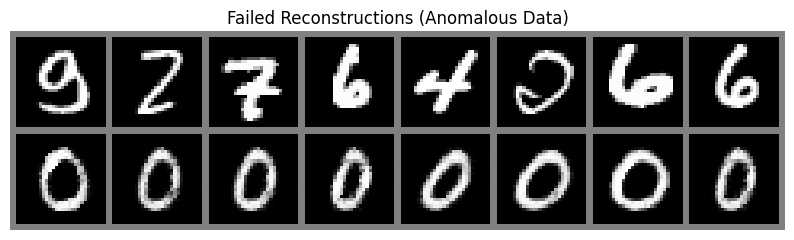

In [ ]:
# --- Configuration ---
normal_class = 0
lr = 0.0002
num_epochs = 15
w_adv = 1
w_con = 50
w_enc = 1

# --- Data Preparation ---
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
full_train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
normal_class_indices = [i for i, target in enumerate(full_train_dataset.targets) if target == normal_class]
normal_train_dataset = torch.utils.data.Subset(full_train_dataset, normal_class_indices)
train_loader_normal = torch.utils.data.DataLoader(normal_train_dataset, batch_size=64, shuffle=True)

full_test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader_full = torch.utils.data.DataLoader(full_test_dataset, batch_size=64, shuffle=False)

# --- Model, Optimizers, and Loss Functions ---
model = GANomaly()
optimizer_G = optim.Adam(model.generator.parameters(), lr=lr, betas=(0.5, 0.999))
optimizer_D = optim.Adam(model.discriminator.parameters(), lr=lr, betas=(0.5, 0.999))
l_adv = nn.BCELoss()
l_con = nn.L1Loss()
l_enc = nn.MSELoss()

# --- Training Loop ---
print(f"--- Starting Training for Normal Class: {normal_class} ---")
for epoch in range(num_epochs):
    model.train()
    loop = tqdm(train_loader_normal, leave=False)
    for i, (imgs, _) in enumerate(loop):
        real_label = torch.ones(imgs.size(0), 1)
        fake_label = torch.zeros(imgs.size(0), 1)

        # Train Generator
        optimizer_G.zero_grad()
        x, z, x_hat, z_hat = model(imgs)
        err_g_adv = l_adv(model.discriminator(z_hat), real_label)
        err_g_con = l_con(x_hat, x)
        err_g_enc = l_enc(z_hat, z)
        err_g = w_adv * err_g_adv + w_con * err_g_con + w_enc * err_g_enc
        err_g.backward(retain_graph=True)
        optimizer_G.step()

        # Train Discriminator
        optimizer_D.zero_grad()

        d_real = model.discriminator(z.detach())
        d_fake = model.discriminator(z_hat.detach())
        err_d_real = l_adv(d_real, real_label)
        err_d_fake = l_adv(d_fake, fake_label)
        err_d = (err_d_real + err_d_fake) * 0.5
        err_d.backward()
        optimizer_D.step()
        loop.set_description(f"Epoch [{epoch+1}/{num_epochs}]")
        loop.set_postfix(G_loss=err_g.item(), D_loss=err_d.item())

# --- Evaluation Phase ---
print("\n--- Starting Evaluation ---")
model.eval()
all_labels = []
all_scores = []
with torch.no_grad():
    for (imgs, labels) in tqdm(test_loader_full, desc="Evaluating"):
        _, z, _, z_hat = model(imgs)
        score = torch.sqrt(torch.sum((z - z_hat) ** 2, dim=[1, 2, 3]))
        all_labels.extend(labels.numpy())
        all_scores.extend(score.numpy())

y_true = np.array([0 if label == normal_class else 1 for label in all_labels])
y_score = np.array(all_scores)

# --- Calculate and Display AUC-ROC ---
fpr, tpr, thresholds = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Receiver Operating Characteristic (Normal Class: {normal_class})')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
print(f"\nAUC Score for normal class '{normal_class}': {roc_auc:.4f}")

# --- Visualize Results ---
def show_reconstructions(dataset, title):
    loader = torch.utils.data.DataLoader(dataset, batch_size=8, shuffle=True)
    images, _ = next(iter(loader))
    with torch.no_grad():
        _, _, reconstructed_images, _ = model(images)
    combined = torch.cat([images, reconstructed_images], 0)
    grid = torchvision.utils.make_grid(combined, nrow=8).numpy()
    grid = grid / 2 + 0.5
    plt.figure(figsize=(10, 3))
    plt.imshow(np.transpose(grid, (1, 2, 0)))
    plt.title(title)
    plt.axis('off')
    plt.show()

normal_test_indices = [i for i, target in enumerate(full_test_dataset.targets) if target == normal_class]
normal_test_subset = torch.utils.data.Subset(full_test_dataset, normal_test_indices)
show_reconstructions(normal_test_subset, "Successful Reconstructions (Normal Data)")

anomaly_test_indices = [i for i, target in enumerate(full_test_dataset.targets) if target != normal_class]
anomaly_test_subset = torch.utils.data.Subset(full_test_dataset, anomaly_test_indices)
show_reconstructions(anomaly_test_subset, "Failed Reconstructions (Anomalous Data)")